In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [3]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (768, 9)

Column names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
print("Class distribution:")
print(df['Outcome'].value_counts())
print("\nAs percentage:")
print(df['Outcome'].value_counts(normalize=True).round(2) * 100)

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

As percentage:
Outcome
0    65.0
1    35.0
Name: proportion, dtype: float64


In [9]:
# In this dataset, 0s in medical columns are actually missing values
# (a glucose of 0 is biologically impossible)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Zero counts (= hidden missing values):")
print((df[zero_cols] == 0).sum())

Zero counts (= hidden missing values):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [10]:
for col in zero_cols:
    median_val = df[col].median()
    df[col] = df[col].replace(0, median_val)

print("Zeros after fix:")
print((df[zero_cols] == 0).sum())

Zeros after fix:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


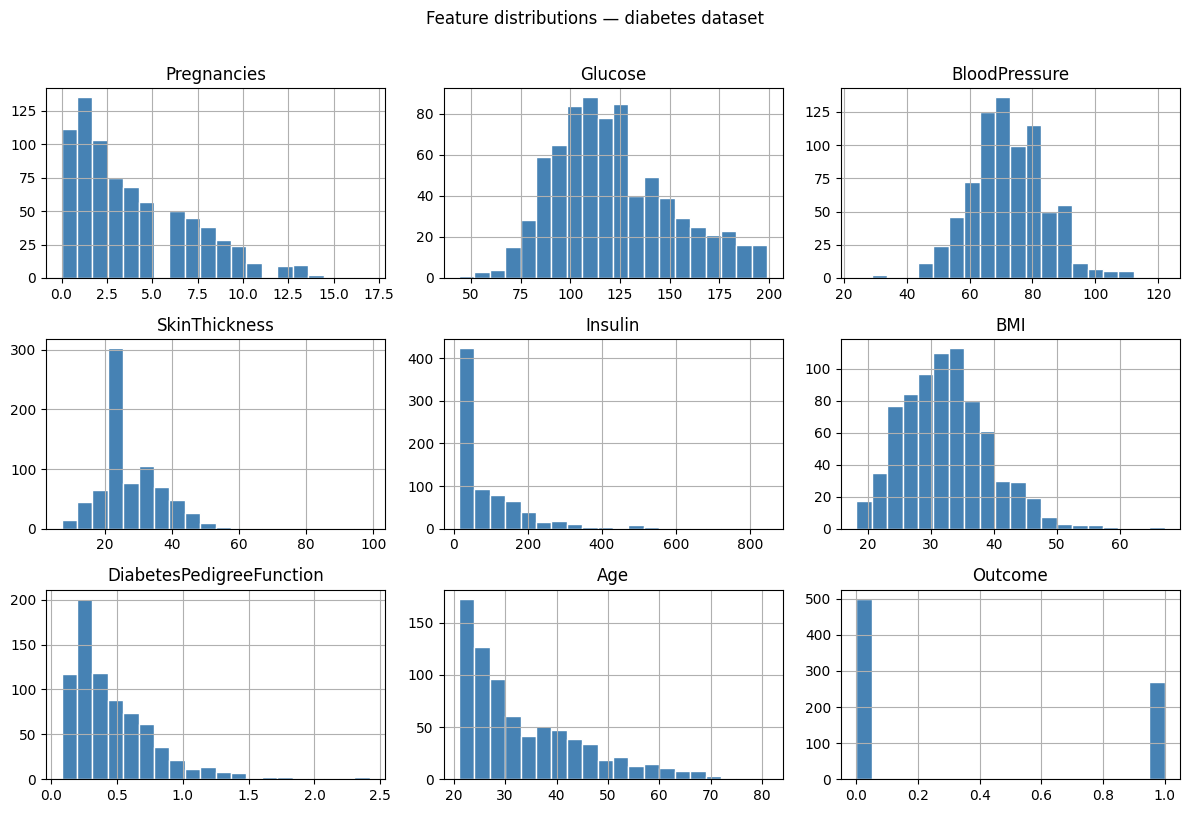

In [11]:
df.hist(figsize=(12, 8), bins=20, color='steelblue', edgecolor='white')
plt.suptitle("Feature distributions — diabetes dataset", y=1.01)
plt.tight_layout()
plt.show()

In [12]:
corr = df.corr()['Outcome'].sort_values(ascending=False)
print("Correlation with Outcome (diabetic):")
print(corr.round(3))

Correlation with Outcome (diabetic):
Outcome                     1.000
Glucose                     0.493
BMI                         0.312
Age                         0.238
Pregnancies                 0.222
SkinThickness               0.189
DiabetesPedigreeFunction    0.174
BloodPressure               0.166
Insulin                     0.148
Name: Outcome, dtype: float64


In [13]:
# Using only Glucose and BMI for the scratch version
# Makes it easy to visualise and reason about distance
X_scratch = df[['Glucose', 'BMI']].values   # numpy array, shape (768, 2)
y_scratch = df['Outcome'].values             # numpy array, shape (768,)

print("X shape:", X_scratch.shape)
print("y shape:", y_scratch.shape)
print("\nFirst 3 rows of X:")
print(X_scratch[:3])
print("\nFirst 3 labels:")
print(y_scratch[:3])

X shape: (768, 2)
y shape: (768,)

First 3 rows of X:
[[148.   33.6]
 [ 85.   26.6]
 [183.   23.3]]

First 3 labels:
[1 0 1]


In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_scratch)

print("Before scaling — Glucose mean: {:.1f}, std: {:.1f}".format(
    X_scratch[:, 0].mean(), X_scratch[:, 0].std()))
print("After scaling  — Glucose mean: {:.1f}, std: {:.1f}".format(
    X_scaled[:, 0].mean(), X_scaled[:, 0].std()))

Before scaling — Glucose mean: 121.7, std: 30.4
After scaling  — Glucose mean: 0.0, std: 1.0


In [15]:
def euclidean_distance(point1, point2):
    """
    Calculate straight-line distance between two points.
    point1, point2 are numpy arrays e.g. [glucose_scaled, bmi_scaled]
    
    Formula: sqrt( sum of (a - b)^2 for each feature )
    """
    return np.sqrt(np.sum((point1 - point2) ** 2))

# Test it manually
priya  = np.array([1.2, 0.8])   # Priya's scaled glucose, BMI
ravi   = np.array([1.3, 0.9])   # Ravi — very close to Priya
meena  = np.array([-1.0, -0.5]) # Meena — far from Priya

print("Distance Priya → Ravi :", round(euclidean_distance(priya, ravi), 4))
print("Distance Priya → Meena:", round(euclidean_distance(priya, meena), 4))
print("Ravi is closer?", euclidean_distance(priya, ravi) < euclidean_distance(priya, meena))

Distance Priya → Ravi : 0.1414
Distance Priya → Meena: 2.5554
Ravi is closer? True


In [16]:
def knn_predict(X_train, y_train, X_test_point, k=5):
    """
    Predict the class for a single test point.
    
    Steps:
      1. Calculate distance from test point to every training point
      2. Sort by distance, pick the k closest
      3. Majority vote among those k neighbours
    """
    # Step 1: calculate distance to every training point
    distances = []
    for i in range(len(X_train)):
        dist = euclidean_distance(X_test_point, X_train[i])
        distances.append((dist, y_train[i]))   # store (distance, label) together
    
    # Step 2: sort by distance (smallest first), take top k
    distances.sort(key=lambda x: x[0])
    k_nearest = distances[:k]
    
    # Step 3: majority vote
    labels = [label for (dist, label) in k_nearest]
    vote_1 = labels.count(1)   # votes for diabetic
    vote_0 = labels.count(0)   # votes for healthy
    
    return 1 if vote_1 > vote_0 else 0


# Quick sanity check — predict for one patient manually
test_patient = X_scaled[0]     # take the first patient from our data
actual_label = y_scratch[0]

prediction = knn_predict(X_scaled[1:], y_scratch[1:], test_patient, k=5)

print("Test patient features (scaled):", test_patient.round(3))
print("Actual label :", actual_label, "→", "Diabetic" if actual_label == 1 else "Healthy")
print("KNN predicted:", prediction, "→", "Diabetic" if prediction == 1 else "Healthy")

Test patient features (scaled): [0.866 0.167]
Actual label : 1 → Diabetic
KNN predicted: 0 → Healthy


In [17]:
# Split first (golden rule: split before scaling — we'll fix this properly in sklearn version)
split = int(0.8 * len(X_scaled))      # 80% train, 20% test
X_train_s, X_test_s = X_scaled[:split], X_scaled[split:]
y_train_s, y_test_s = y_scratch[:split], y_scratch[split:]

print(f"Training on {len(X_train_s)} patients, testing on {len(X_test_s)} patients")
print("Running scratch KNN... (this takes a few seconds — it loops through everything)")

predictions = []
for i in range(len(X_test_s)):
    pred = knn_predict(X_train_s, y_train_s, X_test_s[i], k=5)
    predictions.append(pred)

predictions = np.array(predictions)

# Accuracy
correct = np.sum(predictions == y_test_s)
accuracy = correct / len(y_test_s)
print(f"\nScratch KNN accuracy (k=5): {accuracy:.2%}")
print(f"Correct: {correct} / {len(y_test_s)}")

Training on 614 patients, testing on 154 patients
Running scratch KNN... (this takes a few seconds — it loops through everything)

Scratch KNN accuracy (k=5): 64.94%
Correct: 100 / 154


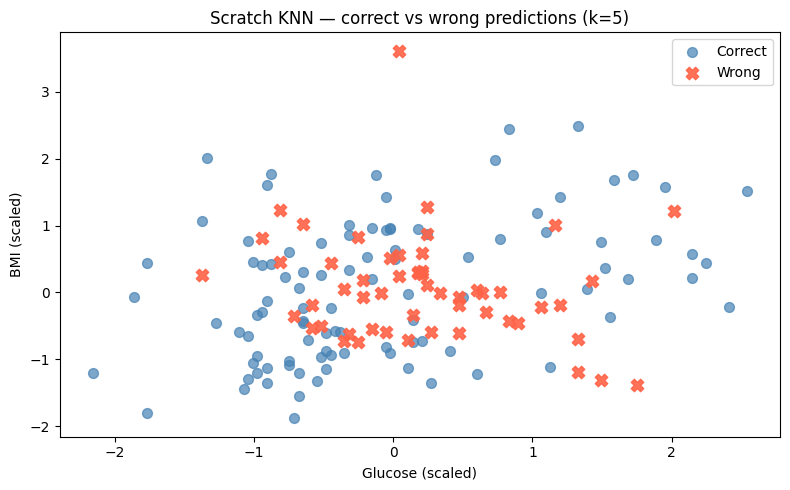


Wrong predictions: 54 out of 154


In [18]:
plt.figure(figsize=(8, 5))

correct_mask   = predictions == y_test_s
incorrect_mask = predictions != y_test_s

plt.scatter(X_test_s[correct_mask, 0],   X_test_s[correct_mask, 1],
            c='steelblue', label='Correct', alpha=0.7, s=50)
plt.scatter(X_test_s[incorrect_mask, 0], X_test_s[incorrect_mask, 1],
            c='tomato',    label='Wrong',   alpha=0.9, s=80, marker='X')

plt.xlabel("Glucose (scaled)")
plt.ylabel("BMI (scaled)")
plt.title("Scratch KNN — correct vs wrong predictions (k=5)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nWrong predictions: {incorrect_mask.sum()} out of {len(y_test_s)}")

In [4]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    df[col] = df[col].replace(0, df[col].median())

print("Zeros fixed. Checking:")
print((df[zero_cols] == 0).sum())

Zeros fixed. Checking:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [5]:
# Using only Glucose and BMI — easy to reason about
X_scratch = df[['Glucose', 'BMI']].values
y_scratch  = df['Outcome'].values

print("X shape:", X_scratch.shape)
print("y shape:", y_scratch.shape)
print("\nFirst 3 patients:")
for i in range(3):
    print(f"  Glucose={X_scratch[i,0]:.1f}, BMI={X_scratch[i,1]:.1f} → {'Diabetic' if y_scratch[i]==1 else 'Healthy'}")

X shape: (768, 2)
y shape: (768,)

First 3 patients:
  Glucose=148.0, BMI=33.6 → Diabetic
  Glucose=85.0, BMI=26.6 → Healthy
  Glucose=183.0, BMI=23.3 → Diabetic


In [6]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_scratch)

print("BEFORE scaling:")
print(f"  Glucose — mean: {X_scratch[:,0].mean():.1f}, std: {X_scratch[:,0].std():.1f}")
print(f"  BMI     — mean: {X_scratch[:,1].mean():.1f}, std: {X_scratch[:,1].std():.1f}")

print("\nAFTER scaling:")
print(f"  Glucose — mean: {X_scaled[:,0].mean():.2f}, std: {X_scaled[:,0].std():.2f}")
print(f"  BMI     — mean: {X_scaled[:,1].mean():.2f}, std: {X_scaled[:,1].std():.2f}")

BEFORE scaling:
  Glucose — mean: 121.7, std: 30.4
  BMI     — mean: 32.5, std: 6.9

AFTER scaling:
  Glucose — mean: 0.00, std: 1.00
  BMI     — mean: 0.00, std: 1.00


In [7]:
def euclidean_distance(point1, point2):
    """
    Straight-line distance between two patients.
    
    point1 = [glucose_scaled, bmi_scaled] of patient A
    point2 = [glucose_scaled, bmi_scaled] of patient B
    
    Formula: sqrt( (g1-g2)^2 + (b1-b2)^2 )
    """
    return np.sqrt(np.sum((point1 - point2) ** 2))

# Test manually with 3 patients
priya = np.array([1.2,  0.8])   # high glucose, high BMI
ravi  = np.array([1.3,  0.9])   # very similar to Priya
meena = np.array([-1.0, -0.5])  # low glucose, low BMI — far from Priya

d1 = euclidean_distance(priya, ravi)
d2 = euclidean_distance(priya, meena)

print(f"Priya → Ravi  : {d1:.4f}  (close)")
print(f"Priya → Meena : {d2:.4f}  (far)")
print(f"\nRavi is closer to Priya? {d1 < d2}")

Priya → Ravi  : 0.1414  (close)
Priya → Meena : 2.5554  (far)

Ravi is closer to Priya? True


In [8]:
def knn_predict_one(X_train, y_train, test_point, k=5):
    """
    Predict class for ONE test patient.
    
    Step 1: measure distance from test_point to every training patient
    Step 2: sort — smallest distance first
    Step 3: take top K neighbours
    Step 4: majority vote → return winning class
    """
    # Step 1 — calculate all distances
    distances = []
    for i in range(len(X_train)):
        dist  = euclidean_distance(test_point, X_train[i])
        label = y_train[i]
        distances.append((dist, label))
    
    # Step 2 — sort by distance (closest first)
    distances.sort(key=lambda x: x[0])
    
    # Step 3 — pick K nearest
    k_nearest = distances[:k]
    
    # Step 4 — majority vote
    labels  = [label for (dist, label) in k_nearest]
    votes_1 = labels.count(1)   # diabetic votes
    votes_0 = labels.count(0)   # healthy votes
    
    print(f"  K={k} neighbours → {votes_1} diabetic, {votes_0} healthy", end=" → ")
    return 1 if votes_1 > votes_0 else 0


# Test on ONE real patient from the dataset
test_patient  = X_scaled[0]
actual_label  = y_scratch[0]

print(f"Patient features (scaled): Glucose={test_patient[0]:.3f}, BMI={test_patient[1]:.3f}")
print(f"Actual: {'Diabetic' if actual_label==1 else 'Healthy'}")
print("Predicting...")

prediction = knn_predict_one(X_scaled[1:], y_scratch[1:], test_patient, k=5)
print(f"Predicted: {'Diabetic' if prediction==1 else 'Healthy'}")
print(f"Correct? {prediction == actual_label}")

Patient features (scaled): Glucose=0.866, BMI=0.167
Actual: Diabetic
Predicting...
  K=5 neighbours → 1 diabetic, 4 healthy → Predicted: Healthy
Correct? False


In [9]:
# Manual 80/20 split
split     = int(0.8 * len(X_scaled))
X_train_s = X_scaled[:split]
X_test_s  = X_scaled[split:]
y_train_s = y_scratch[:split]
y_test_s  = y_scratch[split:]

print(f"Training on {len(X_train_s)} patients")
print(f"Testing  on {len(X_test_s)} patients")
print("\nRunning scratch KNN (may take 10-20 seconds)...\n")

predictions = []
for i in range(len(X_test_s)):
    pred = knn_predict_one(X_train_s, y_train_s, X_test_s[i], k=5)
    predictions.append(pred)

predictions = np.array(predictions)

# Accuracy
correct  = np.sum(predictions == y_test_s)
accuracy = correct / len(y_test_s)

print(f"\n{'='*40}")
print(f"Scratch KNN Accuracy (k=5): {accuracy:.2%}")
print(f"Correct: {correct} / {len(y_test_s)}")
print(f"Wrong  : {len(y_test_s) - correct} / {len(y_test_s)}")

Training on 614 patients
Testing  on 154 patients

Running scratch KNN (may take 10-20 seconds)...

  K=5 neighbours → 5 diabetic, 0 healthy →   K=5 neighbours → 1 diabetic, 4 healthy →   K=5 neighbours → 3 diabetic, 2 healthy →   K=5 neighbours → 0 diabetic, 5 healthy →   K=5 neighbours → 1 diabetic, 4 healthy →   K=5 neighbours → 1 diabetic, 4 healthy →   K=5 neighbours → 2 diabetic, 3 healthy →   K=5 neighbours → 0 diabetic, 5 healthy →   K=5 neighbours → 5 diabetic, 0 healthy →   K=5 neighbours → 1 diabetic, 4 healthy →   K=5 neighbours → 1 diabetic, 4 healthy →   K=5 neighbours → 2 diabetic, 3 healthy →   K=5 neighbours → 0 diabetic, 5 healthy →   K=5 neighbours → 3 diabetic, 2 healthy →   K=5 neighbours → 3 diabetic, 2 healthy →   K=5 neighbours → 0 diabetic, 5 healthy →   K=5 neighbours → 1 diabetic, 4 healthy →   K=5 neighbours → 1 diabetic, 4 healthy →   K=5 neighbours → 1 diabetic, 4 healthy →   K=5 neighbours → 2 diabetic, 3 healthy →   K=5 neighbours → 0 diabetic, 5 healthy

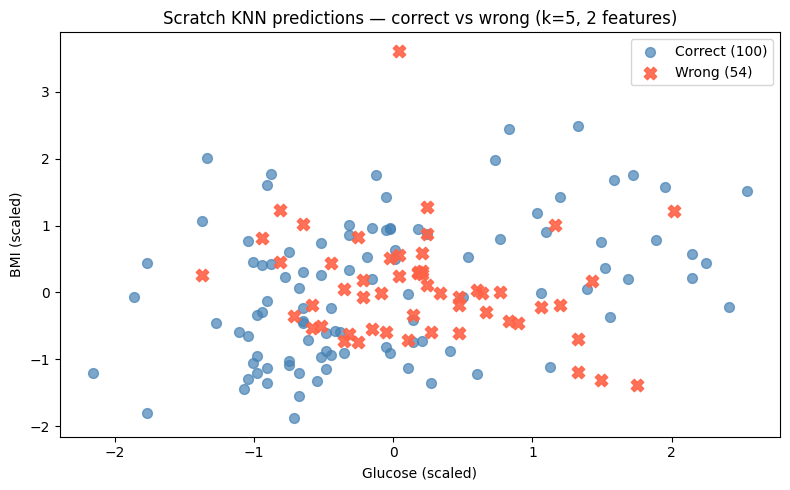

In [10]:
correct_mask   = predictions == y_test_s
incorrect_mask = ~correct_mask

plt.figure(figsize=(8, 5))
plt.scatter(X_test_s[correct_mask,   0], X_test_s[correct_mask,   1],
            c='steelblue', label=f'Correct ({correct_mask.sum()})',
            alpha=0.7, s=50)
plt.scatter(X_test_s[incorrect_mask, 0], X_test_s[incorrect_mask, 1],
            c='tomato', label=f'Wrong ({incorrect_mask.sum()})',
            alpha=0.9, s=80, marker='X')

plt.xlabel("Glucose (scaled)")
plt.ylabel("BMI (scaled)")
plt.title("Scratch KNN predictions — correct vs wrong (k=5, 2 features)")
plt.legend()
plt.tight_layout()
plt.show()
